# Alcanzando los Objetivos de Desarrollo Sostenible
## Clasificación automática de textos mediante procesamiento de lenguaje natural y *machine learning*

| Información académica | Datos |
|---|---|
| **Integrantes** | Alejandro Ocampo Rojas · Mateo Alvarez Lopera |
| **Asignatura** | Machine Learning No Supervisado |
| **Institución** | Universidad de los Andes |
| **Aplicación interactiva** | [Clasificador público en Streamlit](https://microproyecto2-gcrwplkaefh7lt9c7sbryd.streamlit.app) |
| **Repositorio del proyecto** | [GitHub: OcampoA1/Microproyecto2](https://github.com/OcampoA1/Microproyecto2) |

---

### Resumen ejecutivo

Este notebook presenta una solución completa y reproducible para clasificar textos en español según los Objetivos de Desarrollo Sostenible (ODS). Combina dos enfoques complementarios:

- **Aprendizaje no supervisado:** TF-IDF y análisis semántico latente (LSA) para descubrir tópicos.
- **Aprendizaje supervisado:** comparación controlada entre regresión logística y máquinas de soporte vectorial lineales para predecir la etiqueta ODS.

> **Nota metodológica:** LSA constituye el componente no supervisado central, pues descubre estructuras semánticas sin utilizar las etiquetas. La clasificación posterior es supervisada porque el enunciado solicita aprender la relación entre cada texto y su ODS conocido.

Todas las decisiones se validan dentro de un pipeline y el conjunto de prueba permanece aislado hasta la evaluación final. El clasificador seleccionado se calibra para producir probabilidades interpretables y se exporta completo para una aplicación Streamlit.

> **Alcance:** el archivo contiene ejemplos de los ODS 1 a 16, pero ninguno del ODS 17. Por tanto, el sistema solo puede aprender y predecir las 16 clases observadas.

## 1. Objetivo, estrategia y correspondencia con la rúbrica

El objetivo es facilitar el análisis de información textual mediante un modelo capaz de asociar cada documento con el ODS semánticamente más próximo entre las clases disponibles.

| Criterio | Evidencia en el notebook |
|---|---|
| Preparación y reducción de dimensionalidad | Auditoría, TF-IDF, SVD y justificaciones |
| Pipeline de preparación | Pipeline que encapsula TF-IDF, SVD y escalamiento |
| Clasificación y búsqueda de hiperparámetros | Comparación LogisticRegression/LinearSVC mediante GridSearchCV |
| Evaluación sobre datos no vistos | Test reservado, métricas, matriz de confusión y ocho ejemplos |
| LSA e interpretación de tópicos | 15 componentes, términos principales e interpretación de ocho tópicos |
| Despliegue opcional | Pipeline calibrado y persistido con Joblib para Streamlit |

### Decisiones metodológicas

1. **TF-IDF sobre palabras:** pondera términos discriminantes y conserva una representación dispersa eficiente.
2. **Unigramas y bigramas:** combina conceptos individuales con expresiones como “cambio climático” y “derechos humanos”.
3. **Sin stemming agresivo:** conserva palabras legibles para LSA, evita raíces difíciles de interpretar y elimina dependencias de descarga durante el despliegue.
4. **SVD truncado:** reduce la dimensionalidad sin densificar previamente la matriz TF-IDF.
5. **Comparación justa de clasificadores:** todos los candidatos utilizan el mismo split, transformaciones y validación; no se comparan porcentajes obtenidos sobre particiones diferentes.
6. **F1 macro:** cada ODS tiene el mismo peso durante la selección, independientemente de su frecuencia.
7. **Calibración sigmoidal:** convierte los márgenes del LinearSVC ganador en probabilidades estimadas mediante predicciones fuera de muestra del conjunto de entrenamiento.

## 2. Configuración reproducible

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import json
import platform
import tempfile
import textwrap
import warnings

import joblib
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import Markdown, display
from joblib import Memory
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    log_loss,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import Normalizer, StandardScaler
from sklearn.svm import LinearSVC

RANDOM_STATE = 42
TEST_SIZE = 0.20

np.random.seed(RANDOM_STATE)
pd.set_option("display.max_colwidth", 220)
pd.set_option("display.precision", 4)
warnings.filterwarnings("ignore", category=FutureWarning)

plt.style.use("seaborn-v0_8-whitegrid")
mpl.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "font.size": 10,
    "figure.dpi": 110,
})

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"joblib: {joblib.__version__}")

Python: 3.11.15
pandas: 3.0.2
scikit-learn: 1.9.0
joblib: 1.5.3


## 3. Carga y comprensión de los datos

El archivo se carga mediante una ruta relativa para mantener la portabilidad. Antes de modelar se validan el esquema, los tipos, los valores faltantes, los duplicados y el dominio de la variable objetivo.

Esta auditoría es relevante porque la traducción automática y la aumentación reportadas en el enunciado pueden introducir expresiones poco naturales o patrones repetitivos. Por ello, los resultados describen el desempeño sobre este corpus y no garantizan el mismo comportamiento ante cualquier texto ciudadano.

In [2]:
DATA_PATH = Path("Datos_textosODS.xlsx")
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "No se encontró Datos_textosODS.xlsx. Ejecute el notebook desde la carpeta del proyecto."
    )

df = pd.read_excel(DATA_PATH, engine="openpyxl")

expected_columns = {"textos", "ODS"}
if set(df.columns) != expected_columns:
    raise ValueError(f"Se esperaban las columnas {expected_columns}, pero se encontraron {set(df.columns)}")

ODS_NAMES = {
    1: "Fin de la pobreza",
    2: "Hambre cero",
    3: "Salud y bienestar",
    4: "Educación de calidad",
    5: "Igualdad de género",
    6: "Agua limpia y saneamiento",
    7: "Energía asequible y no contaminante",
    8: "Trabajo decente y crecimiento económico",
    9: "Industria, innovación e infraestructura",
    10: "Reducción de las desigualdades",
    11: "Ciudades y comunidades sostenibles",
    12: "Producción y consumo responsables",
    13: "Acción por el clima",
    14: "Vida submarina",
    15: "Vida de ecosistemas terrestres",
    16: "Paz, justicia e instituciones sólidas",
    17: "Alianzas para lograr los objetivos",
}

df["textos"] = df["textos"].astype(str).str.strip()
df["ODS"] = pd.to_numeric(df["ODS"], errors="raise").astype(int)
df["nombre_ODS"] = df["ODS"].map(ODS_NAMES)

if df["nombre_ODS"].isna().any():
    unknown = sorted(df.loc[df["nombre_ODS"].isna(), "ODS"].unique())
    raise ValueError(f"Se encontraron etiquetas ODS desconocidas: {unknown}")

display(df.head(5).assign(textos=lambda x: x["textos"].str.slice(0, 180) + "…"))
print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")

,textos,ODS,nombre_ODS
0,"""Aprendizaje"" y ""educación"" se consideran sinónimos de escolarización formal. Las organizaciones auxiliares, como las editoriales de educación, las juntas examinadoras y las organi…",4,Educación de calidad
1,No dejar clara la naturaleza de estos riesgos puede dar lugar a un exceso de inversión en empresas dependientes del agua y a peticiones de compensación cuando haya que reducir los …,6,Agua limpia y saneamiento
2,"Como resultado, un mayor y mejorado acceso al agua puede afectar aún más la capacidad de adaptación y resiliencia de las comunidades al cambio climático. Para la adaptación, muchos…",13,Acción por el clima
3,"Con el Congreso firmemente en control de la jurisdicción, los recursos y la estructura de los tribunales federales, el alcance de la independencia del poder judicial es ciertamente…",16,"Paz, justicia e instituciones sólidas"
4,"Luego, dos secciones finales analizan las implicaciones para la reconfiguración de las relaciones de cuidado dentro de las familias y la reconfiguración de los ""diamantes del cuida…",5,Igualdad de género


Dimensiones: 9,656 filas × 3 columnas


In [3]:
df["n_palabras"] = df["textos"].str.split().str.len()
df["n_caracteres"] = df["textos"].str.len()

diagnostico = pd.DataFrame({
    "Indicador": [
        "Filas",
        "Textos vacíos",
        "Valores faltantes",
        "Textos duplicados exactos",
        "Número de clases",
        "ODS presentes",
        "ODS ausentes entre 1 y 17",
    ],
    "Resultado": [
        f"{len(df):,}",
        int(df["textos"].eq("").sum()),
        int(df[["textos", "ODS"]].isna().sum().sum()),
        int(df["textos"].duplicated().sum()),
        df["ODS"].nunique(),
        ", ".join(map(str, sorted(df["ODS"].unique()))),
        ", ".join(map(str, sorted(set(range(1, 18)) - set(df["ODS"].unique())))),
    ],
})
display(diagnostico.style.hide(axis="index"))

display(
    df[["n_palabras", "n_caracteres"]]
    .describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95])
    .round(2)
)

Indicador,Resultado
Filas,"9,656"
Textos vacíos,0
Valores faltantes,0
Textos duplicados exactos,0
Número de clases,16
ODS presentes,"1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16"
ODS ausentes entre 1 y 17,17


,n_palabras,n_caracteres
count,9656.00,9656.00
mean,111.02,708.92
std,37.08,238.86
min,24.00,143.00
5%,61.00,387.75
25%,82.00,522.00
50%,105.00,669.00
75%,135.00,864.00
95%,179.00,1153.00
max,268.00,1977.00


### Distribución de clases y longitud documental

La inspección de frecuencias permite cuantificar el desbalance. No se elimina ninguna clase: la estratificación y la métrica F1 macro permiten evaluar de manera explícita los ODS minoritarios. La razón observada entre la clase mayoritaria y la minoritaria es 3.46; no es extrema, pero sí suficiente para que accuracy por sí sola pueda ocultar fallas en ODS con menor representación.

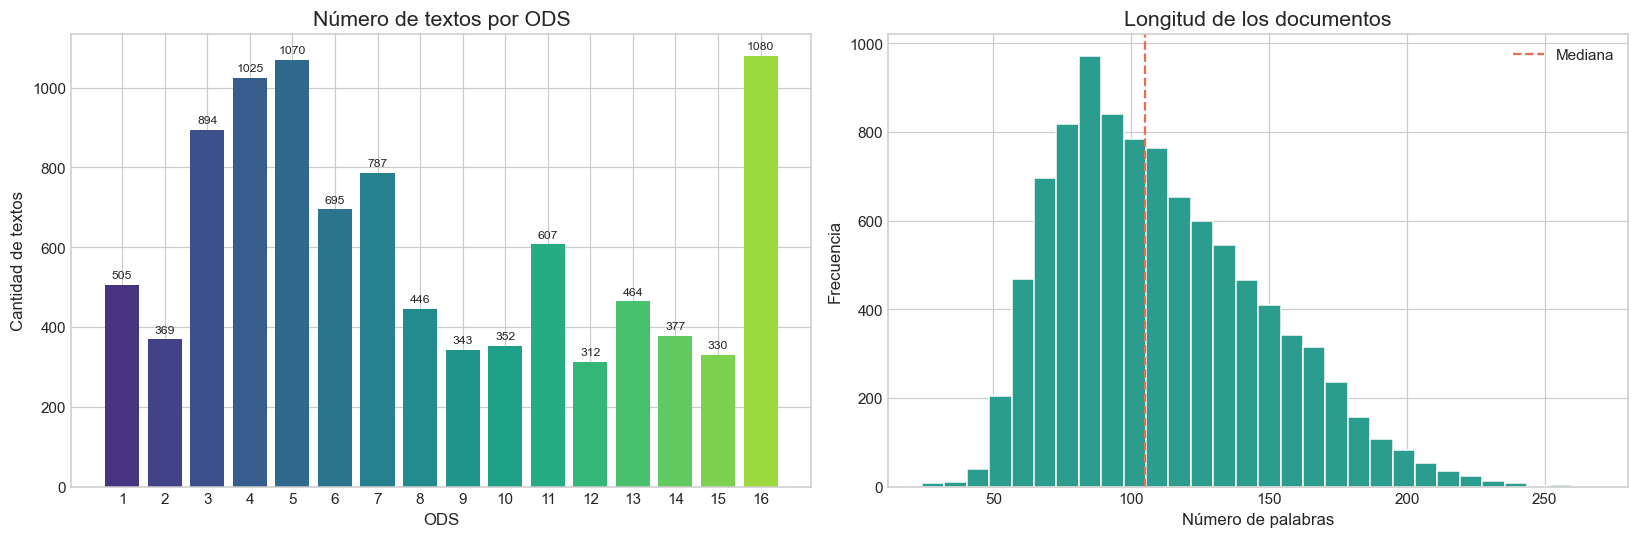

Razón clase mayoritaria/minoritaria: 3.46


,textos,porcentaje,nombre
ODS,,,
1,505,5.23,Fin de la pobreza
2,369,3.82,Hambre cero
3,894,9.26,Salud y bienestar
4,1025,10.62,Educación de calidad
5,1070,11.08,Igualdad de género
6,695,7.20,Agua limpia y saneamiento
7,787,8.15,Energía asequible y no contaminante
8,446,4.62,Trabajo decente y crecimiento económico
9,343,3.55,"Industria, innovación e infraestructura"


In [4]:
class_counts = df["ODS"].value_counts().sort_index()
imbalance_ratio = class_counts.max() / class_counts.min()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(class_counts)))
axes[0].bar(class_counts.index.astype(str), class_counts.values, color=colors)
axes[0].set_title("Número de textos por ODS")
axes[0].set_xlabel("ODS")
axes[0].set_ylabel("Cantidad de textos")
for x, value in zip(class_counts.index, class_counts.values):
    axes[0].text(str(x), value + 12, f"{value}", ha="center", va="bottom", fontsize=8)

axes[1].hist(df["n_palabras"], bins=30, color="#2A9D8F", edgecolor="white")
axes[1].axvline(df["n_palabras"].median(), color="#E76F51", linestyle="--", label="Mediana")
axes[1].set_title("Longitud de los documentos")
axes[1].set_xlabel("Número de palabras")
axes[1].set_ylabel("Frecuencia")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Razón clase mayoritaria/minoritaria: {imbalance_ratio:.2f}")
display(
    class_counts.rename("textos")
    .to_frame()
    .assign(porcentaje=lambda x: 100 * x["textos"] / len(df), nombre=[ODS_NAMES[i] for i in class_counts.index])
    .round({"porcentaje": 2})
)

## 4. Separación de entrenamiento y prueba

Se reserva el 20% del corpus mediante muestreo estratificado. Esta separación ocurre **antes** de ajustar TF-IDF, LSA, SVD o el clasificador. La validación cruzada posterior utiliza únicamente el conjunto de entrenamiento.

In [5]:
X = df["textos"].copy()
y = df["ODS"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

assert set(X_train.index).isdisjoint(set(X_test.index)), "Existe solapamiento entre train y test."
assert len(X_train) + len(X_test) == len(df)

split_distribution = pd.concat(
    [
        y_train.value_counts(normalize=True).sort_index().rename("train"),
        y_test.value_counts(normalize=True).sort_index().rename("test"),
    ],
    axis=1,
).mul(100).round(2)

print(f"Entrenamiento: {len(X_train):,} textos ({len(X_train)/len(df):.0%})")
print(f"Prueba:        {len(X_test):,} textos ({len(X_test)/len(df):.0%})")
display(split_distribution.style.format("{:.2f}%"))

Entrenamiento: 7,724 textos (80%)
Prueba:        1,932 textos (20%)


,train,test
ODS,,
1,5.23%,5.23%
2,3.82%,3.83%
3,9.26%,9.27%
4,10.62%,10.61%
5,11.08%,11.08%
6,7.20%,7.19%
7,8.14%,8.18%
8,4.62%,4.61%
9,3.55%,3.57%


## 5. Preparación de los textos con BOW y TF-IDF

`TfidfVectorizer` implementa una bolsa de palabras dispersa y ponderada. La lista de palabras vacías se incluye localmente para que el notebook no requiera descargas. Como `strip_accents="unicode"` elimina diacríticos antes de tokenizar, la lista también se expresa sin acentos.

Los parámetros `min_df` y `max_df` descartan términos extremadamente raros o ubicuos; `sublinear_tf=True` reduce la influencia de repeticiones dentro de documentos largos. Para clasificación se usan unigramas y bigramas, mientras que el análisis de tópicos utiliza unigramas para facilitar la interpretación.

In [6]:
SPANISH_STOP_WORDS = sorted(set('''
a al algo algunas algunos ante antes aquel aquella aquellas aquello aquellos aqui asi aun aunque
bajo bien cada casi como con contra cual cuales cualquier cuando cuanto de del desde donde dos
durante e el ella ellas ello ellos en entre era eramos eran eras eres es esa esas ese eso esos esta
estaba estaban estado estados estamos estan estar estas este esto estos fue fuera fueron ha haber
habia habian hace hacen hacer hacia hasta hay la las le les lo los mas me menos mi mientras muy nada
ni no nos nosotros o otra otras otro otros para pero poco por porque puede pueden pues que quien
quienes se sea sean ser si sido siempre sin sobre son soy su sus tal tambien tan tanto te tiene
tienen toda todas todo todos tras tu tus un una uno unos usted ustedes ya y
'''.split()))

def make_tfidf(ngram_range=(1, 2), max_features=30_000):
    "Construye un vectorizador nuevo para evitar compartir estado ajustado."
    return TfidfVectorizer(
        lowercase=True,
        strip_accents="unicode",
        stop_words=SPANISH_STOP_WORDS,
        token_pattern=r"(?u)\b[a-zA-ZñÑáéíóúüÁÉÍÓÚÜ]{2,}\b",
        ngram_range=ngram_range,
        min_df=2,
        max_df=0.95,
        max_features=max_features,
        sublinear_tf=True,
        norm="l2",
    )

print(f"Palabras vacías incluidas: {len(SPANISH_STOP_WORDS)}")

Palabras vacías incluidas: 146


## 6. Modelo de tópicos mediante LSA

LSA aproxima la matriz término-documento con factores de menor rango mediante SVD truncado. Se exploran 15 componentes, dentro del rango sugerido de 10 a 20. El ajuste se hace exclusivamente sobre entrenamiento para conservar intacto el conjunto de prueba.

El signo de una componente SVD es arbitrario; aquí se reportan los términos con pesos positivos más altos, que ofrecen la lectura más directa de cada eje semántico.

In [7]:
N_TOPICS = 15
TOP_WORDS = 10

lsa_pipeline = Pipeline([
    ("tfidf", make_tfidf(ngram_range=(1, 1), max_features=None)),
    ("lsa", TruncatedSVD(n_components=N_TOPICS, n_iter=10, random_state=RANDOM_STATE)),
])

X_train_lsa = lsa_pipeline.fit_transform(X_train)
tfidf_topics = lsa_pipeline.named_steps["tfidf"]
lsa_model = lsa_pipeline.named_steps["lsa"]
feature_names = tfidf_topics.get_feature_names_out()
X_train_tfidf = tfidf_topics.transform(X_train)

topic_rows = []
for topic_idx, component in enumerate(lsa_model.components_, start=1):
    top_indices = component.argsort()[-TOP_WORDS:][::-1]
    top_terms = feature_names[top_indices]
    top_weights = component[top_indices]
    topic_rows.append({
        "Componente": topic_idx,
        "Términos principales": ", ".join(top_terms),
        "Peso máximo": top_weights[0],
    })

topics_df = pd.DataFrame(topic_rows)

print(f"Matriz TF-IDF de entrenamiento: {X_train_tfidf.shape[0]:,} × {X_train_tfidf.shape[1]:,}")
print(f"Densidad: {X_train_tfidf.nnz / np.prod(X_train_tfidf.shape):.4%}")
print(f"Representación LSA: {X_train_lsa.shape}")
print(f"Varianza explicada acumulada (15 componentes): {lsa_model.explained_variance_ratio_.sum():.2%}")
display(topics_df.style.format({"Peso máximo": "{:.4f}"}).hide(axis="index"))

Matriz TF-IDF de entrenamiento: 7,724 × 15,838
Densidad: 0.2878%
Representación LSA: (7724, 15)
Varianza explicada acumulada (15 componentes): 3.84%


Componente,Términos principales,Peso máximo
1,"paises, mujeres, desarrollo, politicas, han, educacion, ocde, agua, mayor, nivel",0.1573
2,"mujeres, hombres, genero, laboral, educacion, pobreza, trabajo, empleo, ingresos, ninos",0.3771
3,"derechos, derecho, humanos, internacional, articulo, mujeres, genero, ley, igualdad, internacionales",0.3059
4,"educacion, estudiantes, escuelas, aprendizaje, escuela, atencion, docentes, salud, evaluacion, escolar",0.2630
5,"mujeres, genero, hombres, igualdad, energia, politicas, desarrollo, participacion, empresas, agua",0.3763
6,"salud, atencion, servicios, mental, agua, pacientes, mujeres, medicos, calidad, primaria",0.4354
7,"agua, aguas, gestion, subterraneas, residuales, hidricos, potable, riego, recursos, estudiantes",0.5893
8,"energia, electricidad, derecho, renovables, derechos, energetica, generacion, energias, humanos, educacion",0.3040
9,"paises, ocde, climatico, promedio, anos, millones, datos, financiacion, cambio, mujeres",0.3319
10,"pobreza, energia, genero, ninos, energetica, igualdad, electricidad, renovables, infantil, energias",0.3230


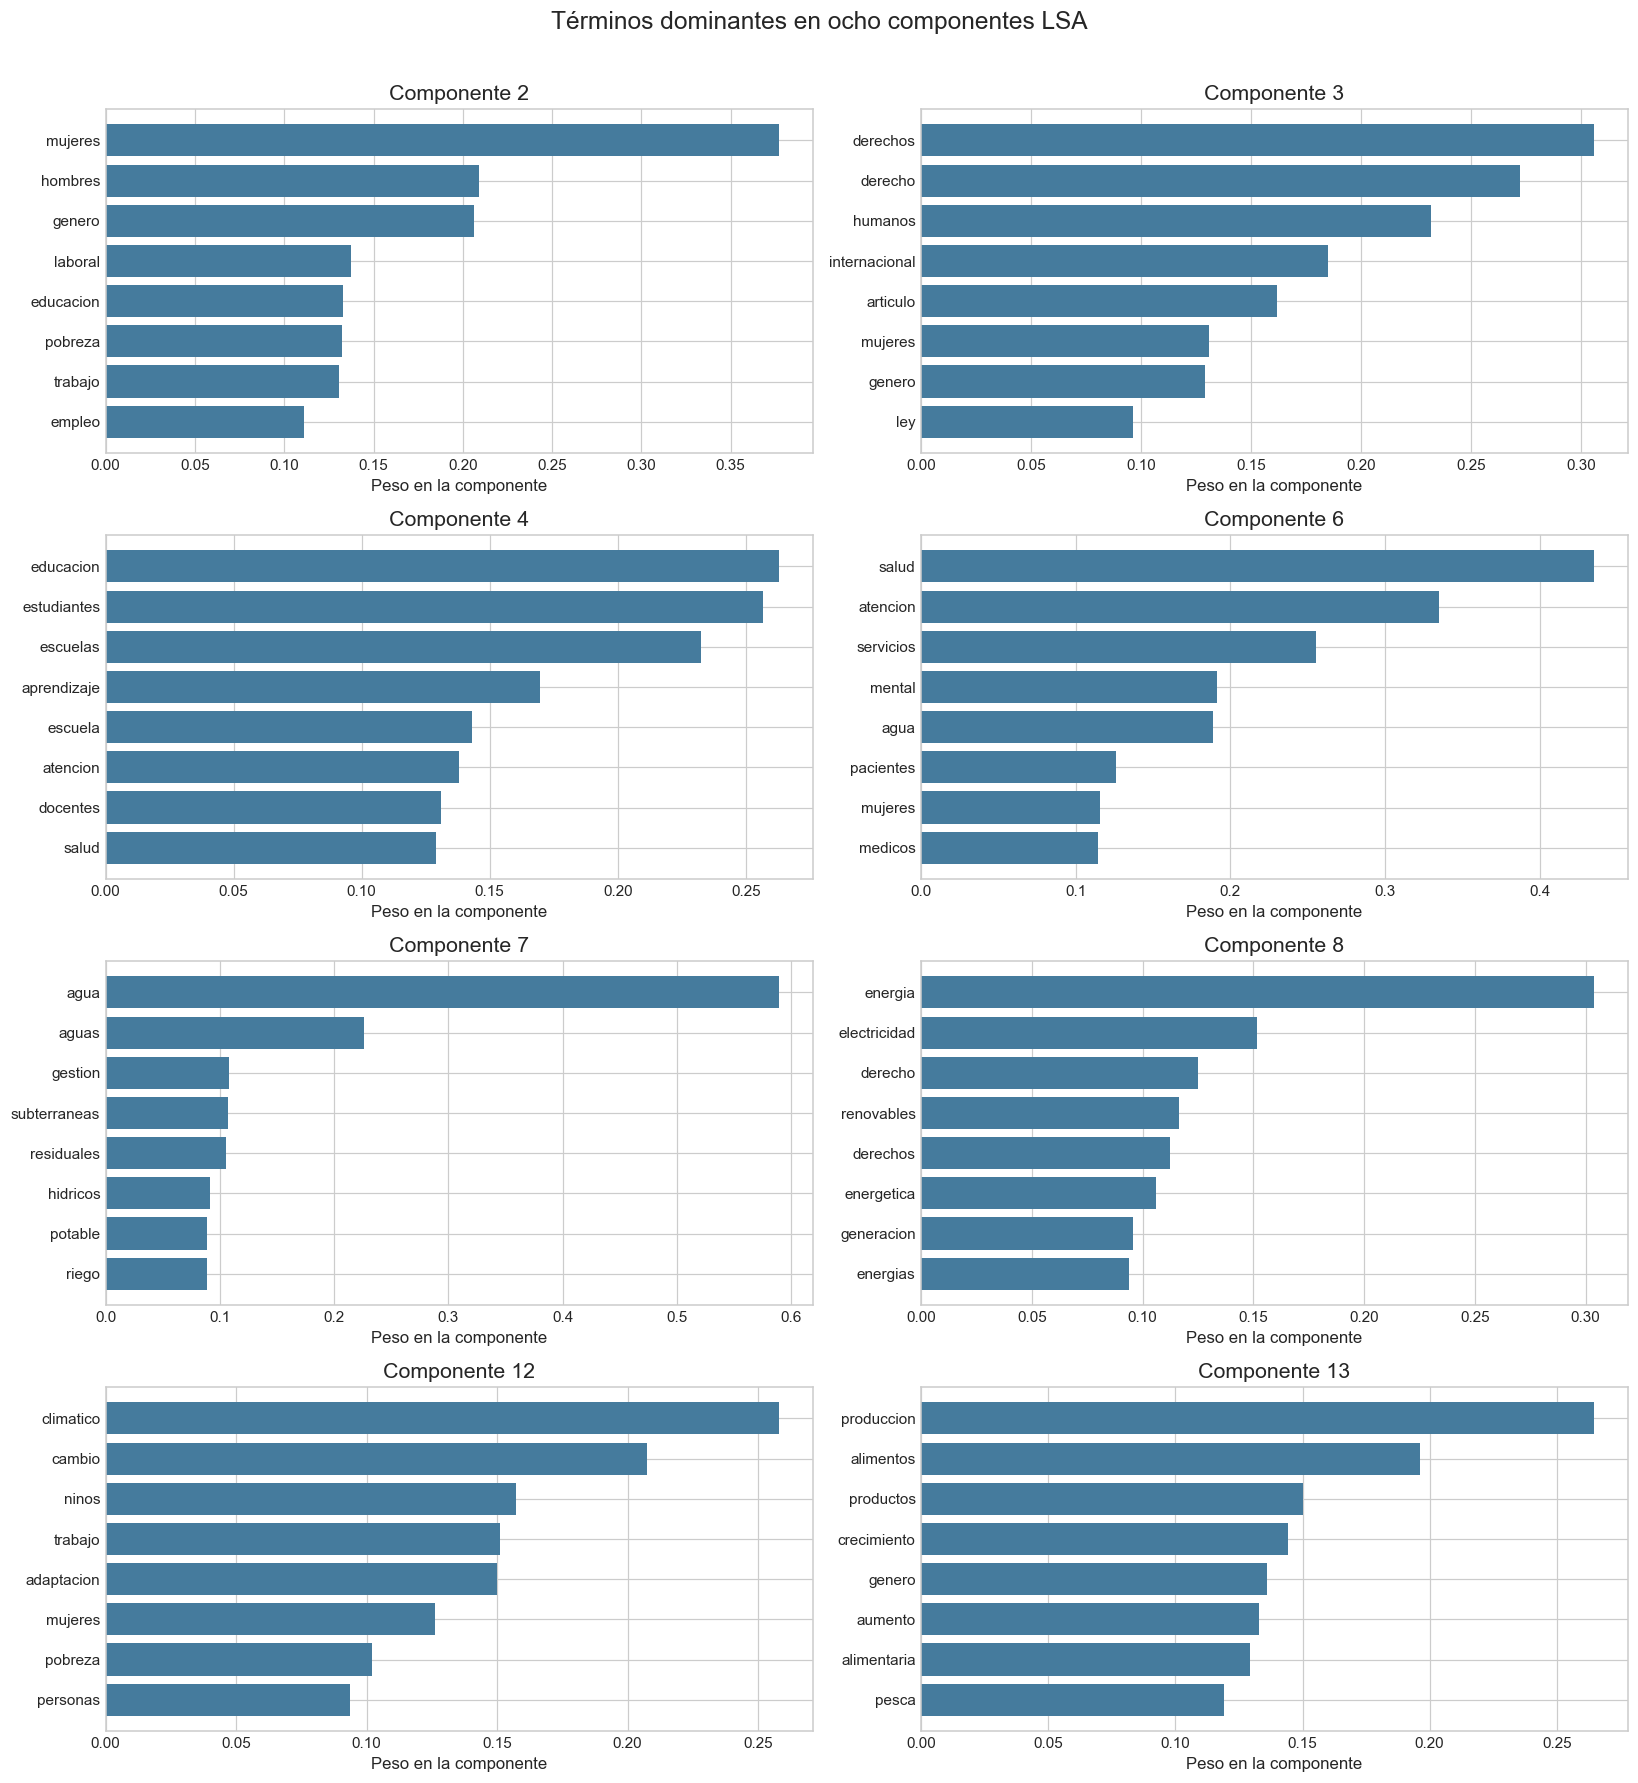

In [8]:
SELECTED_TOPICS = [2, 3, 4, 6, 7, 8, 12, 13]
fig, axes = plt.subplots(4, 2, figsize=(15, 16))
axes = axes.ravel()

for ax, topic_number in zip(axes, SELECTED_TOPICS):
    component = lsa_model.components_[topic_number - 1]
    top_idx = component.argsort()[-8:]
    ax.barh(feature_names[top_idx], component[top_idx], color="#457B9D")
    ax.set_title(f"Componente {topic_number}")
    ax.set_xlabel("Peso en la componente")

plt.suptitle("Términos dominantes en ocho componentes LSA", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### Interpretación cualitativa frente a los ODS

La interpretación se basa en conjuntos de términos, no en palabras aisladas. Los solapamientos son esperables porque muchos problemas de desarrollo sostenible son transversales; por ejemplo, pobreza, género, educación y empleo aparecen relacionados.

Los 15 componentes explican 3.84% de la varianza, un valor bajo en términos absolutos pero esperable en una matriz textual dispersa con 15,838 términos. Por esta razón, LSA no se evalúa únicamente por la varianza acumulada, sino también por la coherencia semántica de los términos y la presencia de ejes interpretables. Ocho componentes presentan asociaciones plausibles con los ODS, mientras que los cruces entre objetivos muestran que el método descubre temas latentes y no reproduce mecánicamente las etiquetas.

In [9]:
interpretations = [
    (2, "ODS 5, 8 y 1", "Género, empleo e ingresos", "La presencia conjunta de mujeres, hombres, género, trabajo e ingresos conecta igualdad, trabajo decente y pobreza."),
    (3, "ODS 16 y 5", "Derechos, justicia e igualdad", "Derechos humanos, ley, justicia, violencia e igualdad describen instituciones y protección de derechos."),
    (4, "ODS 4", "Educación de calidad", "Estudiantes, escuelas, aprendizaje, docentes y evaluación forman un tópico educativo muy definido."),
    (6, "ODS 3", "Salud y bienestar", "Salud, atención, pacientes, servicios, enfermedades y personal médico representan provisión sanitaria."),
    (7, "ODS 6", "Agua limpia y saneamiento", "Agua, aguas residuales, recursos hídricos, riego y agua potable se alinean directamente con el ODS 6."),
    (8, "ODS 7", "Energía asequible y limpia", "Energía, electricidad, renovables, generación y eficiencia caracterizan la transición energética."),
    (12, "ODS 13", "Cambio climático y adaptación", "Cambio climático, adaptación, financiación y tiempo reflejan respuestas sociales y económicas frente al clima."),
    (13, "ODS 12, 2 y 14", "Producción, alimentos y recursos", "Producción, consumo, alimentos, pesca y recursos revelan relaciones entre consumo responsable, seguridad alimentaria y océanos."),
]

interpretation_df = pd.DataFrame(
    interpretations,
    columns=["Componente", "ODS relacionados", "Lectura", "Justificación"],
)
interpretation_df["Términos observados"] = interpretation_df["Componente"].map(
    topics_df.set_index("Componente")["Términos principales"]
)
display(interpretation_df.style.hide(axis="index"))

Componente,ODS relacionados,Lectura,Justificación,Términos observados
2,"ODS 5, 8 y 1","Género, empleo e ingresos","La presencia conjunta de mujeres, hombres, género, trabajo e ingresos conecta igualdad, trabajo decente y pobreza.","mujeres, hombres, genero, laboral, educacion, pobreza, trabajo, empleo, ingresos, ninos"
3,ODS 16 y 5,"Derechos, justicia e igualdad","Derechos humanos, ley, justicia, violencia e igualdad describen instituciones y protección de derechos.","derechos, derecho, humanos, internacional, articulo, mujeres, genero, ley, igualdad, internacionales"
4,ODS 4,Educación de calidad,"Estudiantes, escuelas, aprendizaje, docentes y evaluación forman un tópico educativo muy definido.","educacion, estudiantes, escuelas, aprendizaje, escuela, atencion, docentes, salud, evaluacion, escolar"
6,ODS 3,Salud y bienestar,"Salud, atención, pacientes, servicios, enfermedades y personal médico representan provisión sanitaria.","salud, atencion, servicios, mental, agua, pacientes, mujeres, medicos, calidad, primaria"
7,ODS 6,Agua limpia y saneamiento,"Agua, aguas residuales, recursos hídricos, riego y agua potable se alinean directamente con el ODS 6.","agua, aguas, gestion, subterraneas, residuales, hidricos, potable, riego, recursos, estudiantes"
8,ODS 7,Energía asequible y limpia,"Energía, electricidad, renovables, generación y eficiencia caracterizan la transición energética.","energia, electricidad, derecho, renovables, derechos, energetica, generacion, energias, humanos, educacion"
12,ODS 13,Cambio climático y adaptación,"Cambio climático, adaptación, financiación y tiempo reflejan respuestas sociales y económicas frente al clima.","climatico, cambio, ninos, trabajo, adaptacion, mujeres, pobreza, personas, tiempo, financiacion"
13,"ODS 12, 2 y 14","Producción, alimentos y recursos","Producción, consumo, alimentos, pesca y recursos revelan relaciones entre consumo responsable, seguridad alimentaria y océanos.","produccion, alimentos, productos, crecimiento, genero, aumento, alimentaria, pesca, precios, recursos"


## 7. Comparación de clasificadores y búsqueda de hiperparámetros

Se construye un único pipeline **TF-IDF → SVD → escalamiento → clasificador**. La búsqueda compara dos familias bajo las mismas particiones:

- **Regresión logística**, con normalización L2 de la representación LSA.
- **LinearSVC**, tanto con normalización L2 como con estandarización de cada componente SVD.

LinearSVC es especialmente apropiado para clasificación de texto porque optimiza márgenes lineales y escala bien a espacios con muchas características. `StandardScaler` puede ser útil después de SVD porque las componentes ya son densas y presentan varianzas diferentes. Los valores de `C` se adaptan a la escala de cada representación.

La búsqueda usa tres particiones estratificadas y selecciona por F1 macro. Cada fold ajusta desde cero su vocabulario, IDF, SVD, escalador y clasificador, evitando fuga de información. La caché es temporal y solo evita repetir transformaciones idénticas.

In [10]:
def make_classification_pipeline(memory=None):
    return Pipeline(
        steps=[
            ("tfidf", make_tfidf(ngram_range=(1, 2), max_features=30_000)),
            ("svd", TruncatedSVD(n_components=300, n_iter=7, random_state=RANDOM_STATE)),
            ("scaler", Normalizer(copy=False)),
            ("classifier", LogisticRegression(
                max_iter=2_000,
                solver="lbfgs",
                random_state=RANDOM_STATE,
            )),
        ],
        memory=memory,
    )

param_grid = [
    {
        "classifier": [LogisticRegression(max_iter=2_000, solver="lbfgs", random_state=RANDOM_STATE)],
        "scaler": [Normalizer(copy=False)],
        "svd__n_components": [100, 200, 300],
        "classifier__C": [1.0, 3.0],
        "classifier__class_weight": [None, "balanced"],
    },
    {
        "classifier": [LinearSVC(max_iter=5_000, random_state=RANDOM_STATE)],
        "scaler": [Normalizer(copy=False)],
        "svd__n_components": [100, 200, 300],
        "classifier__C": [0.1, 0.5, 1.0],
        "classifier__class_weight": [None, "balanced"],
    },
    {
        "classifier": [LinearSVC(max_iter=5_000, random_state=RANDOM_STATE)],
        "scaler": [StandardScaler()],
        "svd__n_components": [100, 200, 300],
        "classifier__C": [0.001, 0.01, 0.1],
        "classifier__class_weight": [None, "balanced"],
    },
]

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

with tempfile.TemporaryDirectory(prefix="ods_pipeline_cache_") as cache_dir:
    pipeline = make_classification_pipeline(memory=Memory(cache_dir, verbose=0))
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        verbose=1,
        return_train_score=True,
        error_score="raise",
    )
    grid_search.fit(X_train, y_train)
    best_uncalibrated = grid_search.best_estimator_

best_uncalibrated.memory = None
best_params_display = {
    key: type(value).__name__ if key in {"classifier", "scaler"} else value
    for key, value in grid_search.best_params_.items()
}

print(f"Configuraciones evaluadas: {len(grid_search.cv_results_['params'])}")
print(f"Mejor F1 macro promedio en validación: {grid_search.best_score_:.4f}")
print("Mejor configuración:")
print(json.dumps(best_params_display, indent=2, ensure_ascii=False))

Fitting 3 folds for each of 48 candidates, totalling 144 fits


Configuraciones evaluadas: 48
Mejor F1 macro promedio en validación: 0.8462
Mejor configuración:
{
  "classifier": "LinearSVC",
  "classifier__C": 0.001,
  "classifier__class_weight": "balanced",
  "scaler": "StandardScaler",
  "svd__n_components": 300
}


In [11]:
cv_results = pd.DataFrame(grid_search.cv_results_).copy()
cv_results["modelo"] = cv_results["param_classifier"].map(lambda value: type(value).__name__)
cv_results["escalamiento"] = cv_results["param_scaler"].map(lambda value: type(value).__name__)

comparison = (
    cv_results[[
        "rank_test_score", "modelo", "escalamiento", "mean_test_score",
        "std_test_score", "mean_train_score", "param_svd__n_components",
        "param_classifier__C", "param_classifier__class_weight", "mean_fit_time",
    ]]
    .sort_values(["rank_test_score", "mean_test_score"])
    .rename(columns={
        "rank_test_score": "ranking",
        "mean_test_score": "F1_macro_validación",
        "std_test_score": "desv_validación",
        "mean_train_score": "F1_macro_entrenamiento",
        "param_svd__n_components": "componentes_SVD",
        "param_classifier__C": "C",
        "param_classifier__class_weight": "peso_clases",
        "mean_fit_time": "tiempo_ajuste_s",
    })
)

best_by_family = (
    comparison.sort_values("F1_macro_validación", ascending=False)
    .groupby("modelo", as_index=False)
    .first()
    .sort_values("F1_macro_validación", ascending=False)
)

print("Mejor configuración de cada familia:")
display(best_by_family.style.format({
    "F1_macro_validación": "{:.4f}",
    "desv_validación": "{:.4f}",
    "F1_macro_entrenamiento": "{:.4f}",
    "tiempo_ajuste_s": "{:.2f}",
}).hide(axis="index"))

print("Quince configuraciones principales:")
display(comparison.head(15).style.format({
    "F1_macro_validación": "{:.4f}",
    "desv_validación": "{:.4f}",
    "F1_macro_entrenamiento": "{:.4f}",
    "tiempo_ajuste_s": "{:.2f}",
}).hide(axis="index"))

Mejor configuración de cada familia:


modelo,ranking,escalamiento,F1_macro_validación,desv_validación,F1_macro_entrenamiento,componentes_SVD,C,peso_clases,tiempo_ajuste_s
LinearSVC,1,StandardScaler,0.8462,0.0027,0.8919,300,0.001000,balanced,4.68
LogisticRegression,3,Normalizer,0.8443,0.0067,0.9371,300,3.000000,balanced,0.81


Quince configuraciones principales:


ranking,modelo,escalamiento,F1_macro_validación,desv_validación,F1_macro_entrenamiento,componentes_SVD,C,peso_clases,tiempo_ajuste_s
1,LinearSVC,StandardScaler,0.8462,0.0027,0.8919,300,0.001000,balanced,4.68
2,LinearSVC,Normalizer,0.8444,0.0040,0.8991,300,0.100000,balanced,5.44
3,LogisticRegression,Normalizer,0.8443,0.0067,0.9371,300,3.000000,nan,0.81
4,LinearSVC,Normalizer,0.8440,0.0065,0.9342,300,0.500000,balanced,4.70
5,LinearSVC,Normalizer,0.8440,0.0040,0.9312,300,0.500000,nan,5.00
6,LinearSVC,StandardScaler,0.8409,0.0052,0.9356,300,0.010000,nan,4.30
7,LogisticRegression,Normalizer,0.8406,0.0045,0.9089,300,1.000000,balanced,11.98
8,LogisticRegression,Normalizer,0.8405,0.0022,0.9056,300,1.000000,nan,17.91
9,LinearSVC,Normalizer,0.8405,0.0060,0.8967,300,0.100000,nan,4.97
10,LinearSVC,Normalizer,0.8404,0.0057,0.9468,300,1.000000,nan,4.97


### 7.1 Calibración del clasificador seleccionado

La búsqueda produjo resultados muy próximos: F1 macro de validación de 0.846 para LinearSVC y 0.844 para regresión logística. En consecuencia, la selección de LinearSVC no se presenta como una superioridad amplia, sino como una mejora pequeña y reproducible bajo el mismo protocolo, acompañada por una menor brecha entre entrenamiento y validación.

`LinearSVC` produce distancias a hiperplanos, no probabilidades. Aplicar directamente softmax a esos márgenes generaría valores que suman uno, pero **no probabilidades calibradas**. Para que la aplicación pueda comunicar incertidumbre de forma responsable, se aplica calibración sigmoidal mediante `CalibratedClassifierCV`.

Con `ensemble=False`, scikit-learn obtiene predicciones fuera de muestra dentro del entrenamiento para ajustar la calibración y finalmente entrena un único pipeline base sobre todo el conjunto de entrenamiento. El test continúa completamente aislado.

In [12]:
calibration_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
final_model = CalibratedClassifierCV(
    estimator=clone(best_uncalibrated),
    method="sigmoid",
    cv=calibration_cv,
    n_jobs=-1,
    ensemble=False,
)
final_model.fit(X_train, y_train)

fitted_pipeline = final_model.calibrated_classifiers_[0].estimator
fitted_vectorizer = fitted_pipeline.named_steps["tfidf"]

print(f"Modelo base calibrado: {type(fitted_pipeline.named_steps['classifier']).__name__}")
print(f"Método de calibración: {final_model.method}")
print(f"Clases soportadas: {', '.join(map(str, final_model.classes_))}")

Modelo base calibrado: LinearSVC
Método de calibración: sigmoid
Clases soportadas: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16


## 8. Evaluación final sobre textos no vistos

El test se utiliza por primera vez en esta sección. Se reportan métricas complementarias:

- **Accuracy:** proporción global de aciertos.
- **Balanced accuracy:** promedio del recall entre clases.
- **F1 macro:** asigna el mismo peso a cada ODS y es la métrica principal.
- **F1 ponderado:** pondera el F1 por el soporte real de cada clase.
- **Log-loss:** evalúa la calidad de las probabilidades calibradas y penaliza predicciones incorrectas con excesiva seguridad.

In [13]:
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Balanced accuracy": balanced_accuracy_score(y_test, y_pred),
    "F1 macro": f1_score(y_test, y_pred, average="macro"),
    "F1 ponderado": f1_score(y_test, y_pred, average="weighted"),
    "Log-loss": log_loss(y_test, y_proba, labels=final_model.classes_),
}

metrics_df = pd.DataFrame.from_dict(metrics, orient="index", columns=["Valor"])
display(metrics_df.style.format("{:.4f}"))

report = classification_report(
    y_test,
    y_pred,
    labels=sorted(y.unique()),
    target_names=[f"ODS {i}: {ODS_NAMES[i]}" for i in sorted(y.unique())],
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report).T
display(report_df.style.format("{:.4f}"))

,Valor
Accuracy,0.8820
Balanced accuracy,0.8545
F1 macro,0.8531
F1 ponderado,0.8813
Log-loss,0.4410


,precision,recall,f1-score,support
ODS 1: Fin de la pobreza,0.8602,0.7921,0.8247,101.0000
ODS 2: Hambre cero,0.7791,0.9054,0.8375,74.0000
ODS 3: Salud y bienestar,0.9076,0.9330,0.9201,179.0000
ODS 4: Educación de calidad,0.9481,0.9805,0.9640,205.0000
ODS 5: Igualdad de género,0.9434,0.9346,0.9390,214.0000
ODS 6: Agua limpia y saneamiento,0.9394,0.8921,0.9151,139.0000
ODS 7: Energía asequible y no contaminante,0.9304,0.9304,0.9304,158.0000
ODS 8: Trabajo decente y crecimiento económico,0.6265,0.5843,0.6047,89.0000
"ODS 9: Industria, innovación e infraestructura",0.6709,0.7681,0.7162,69.0000
ODS 10: Reducción de las desigualdades,0.7288,0.6143,0.6667,70.0000


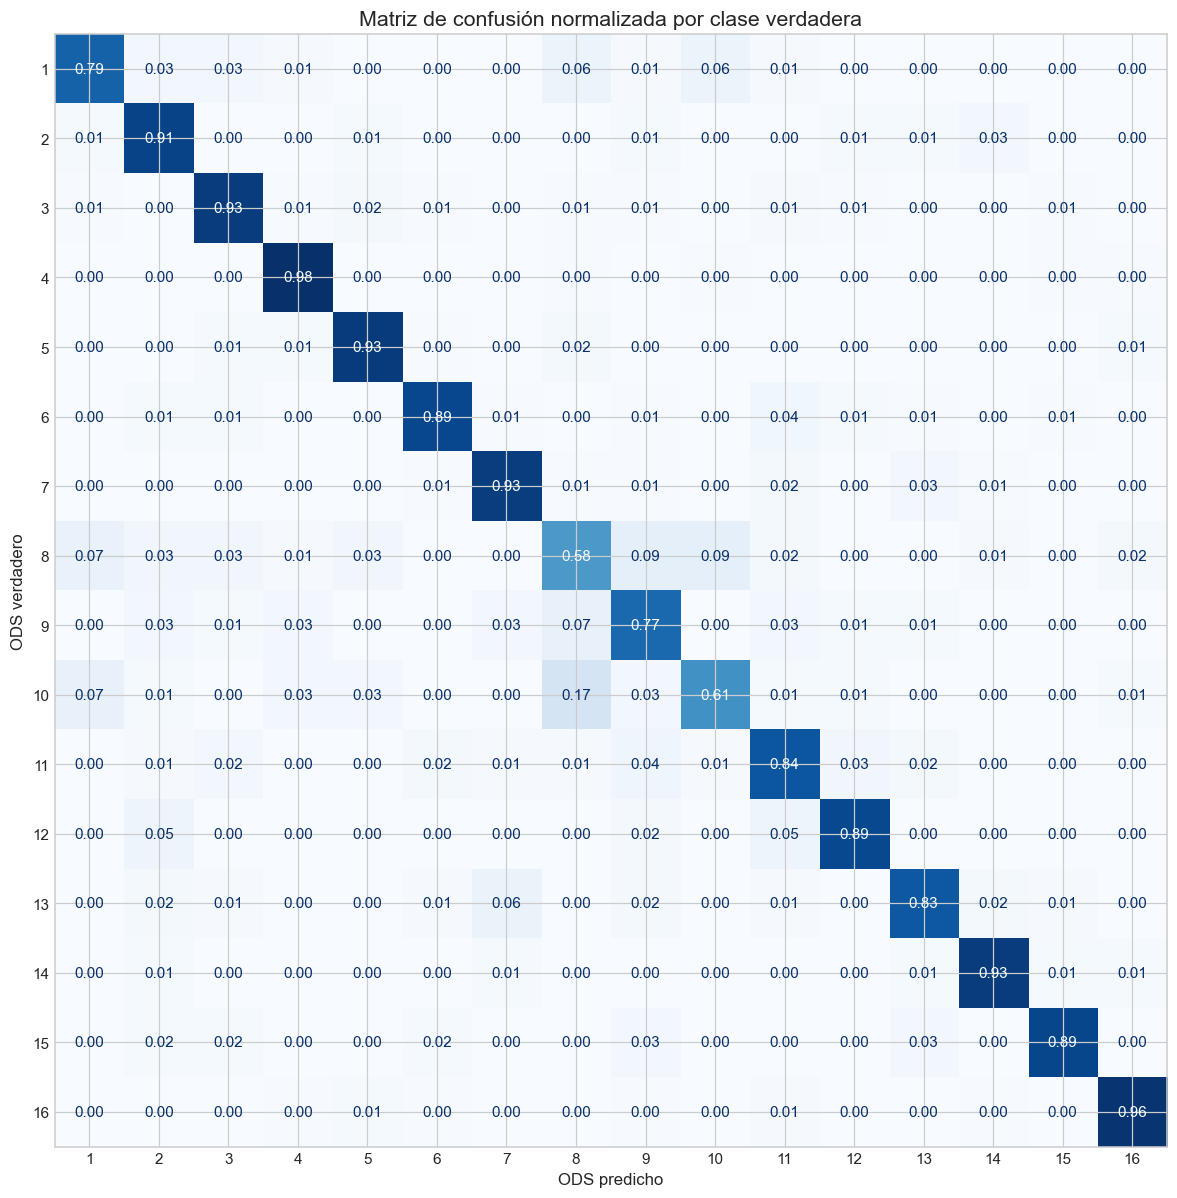

In [14]:
labels = sorted(y.unique())
fig, ax = plt.subplots(figsize=(13, 11))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=labels,
    display_labels=[str(i) for i in labels],
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    colorbar=False,
    ax=ax,
)
ax.set_title("Matriz de confusión normalizada por clase verdadera")
ax.set_xlabel("ODS predicho")
ax.set_ylabel("ODS verdadero")
plt.tight_layout()
plt.show()

### Análisis de errores por clase

El recall permite identificar qué ODS pierde más ejemplos verdaderos; la precisión muestra cuáles reciben más falsos positivos. La siguiente tabla se ordena por F1 para dirigir la inspección hacia las clases más difíciles.

El accuracy de 0.882 supera al F1 macro de 0.853 y al balanced accuracy de 0.854. Esta diferencia es coherente con el desbalance moderado: el desempeño global es alto, pero no homogéneo entre ODS. En particular, los ODS 8, 10 y 9 presentan los menores F1; su vocabulario se cruza con empleo, desigualdad, industria y desarrollo económico. En una aplicación real, estos casos deberían priorizarse para revisión humana o para ampliar el corpus con ejemplos más discriminantes.

In [15]:
per_class = report_df.loc[[f"ODS {i}: {ODS_NAMES[i]}" for i in labels]].copy()
per_class.index.name = "Clase"
per_class = per_class.sort_values("f1-score")
display(per_class.style.format("{:.4f}"))

worst = per_class.head(3)
print("Clases con menor F1 en el conjunto de prueba:")
for class_name, row in worst.iterrows():
    print(f"- {class_name}: F1={row['f1-score']:.3f}, recall={row['recall']:.3f}")

,precision,recall,f1-score,support
Clase,,,,
ODS 8: Trabajo decente y crecimiento económico,0.6265,0.5843,0.6047,89.0000
ODS 10: Reducción de las desigualdades,0.7288,0.6143,0.6667,70.0000
"ODS 9: Industria, innovación e infraestructura",0.6709,0.7681,0.7162,69.0000
ODS 1: Fin de la pobreza,0.8602,0.7921,0.8247,101.0000
ODS 11: Ciudades y comunidades sostenibles,0.8226,0.8361,0.8293,122.0000
ODS 2: Hambre cero,0.7791,0.9054,0.8375,74.0000
ODS 13: Acción por el clima,0.8652,0.8280,0.8462,93.0000
ODS 12: Producción y consumo responsables,0.8462,0.8871,0.8661,62.0000
ODS 15: Vida de ecosistemas terrestres,0.9219,0.8939,0.9077,66.0000


Clases con menor F1 en el conjunto de prueba:
- ODS 8: Trabajo decente y crecimiento económico: F1=0.605, recall=0.584
- ODS 10: Reducción de las desigualdades: F1=0.667, recall=0.614
- ODS 9: Industria, innovación e infraestructura: F1=0.716, recall=0.768


## 9. Evidencia de predicción sobre textos del conjunto de prueba

Se seleccionan ocho documentos de clases diversas. Ninguno participó en el ajuste del vectorizador, SVD o clasificador. La “confianza” corresponde a la probabilidad máxima estimada mediante la calibración sigmoidal del LinearSVC y debe interpretarse como orientación, no como certeza causal.

In [16]:
EVIDENCE_CLASSES = [1, 3, 4, 5, 6, 7, 13, 16]
evidence_indices = []
for ods in EVIDENCE_CLASSES:
    candidates = y_test[y_test == ods]
    evidence_indices.append(candidates.sample(1, random_state=RANDOM_STATE + ods).index[0])

class_to_col = {int(label): i for i, label in enumerate(final_model.classes_)}
evidence_rows = []
for idx in evidence_indices:
    pos = X_test.index.get_loc(idx)
    true_label = int(y_test.loc[idx])
    pred_label = int(y_pred[pos])
    confidence = float(y_proba[pos, class_to_col[pred_label]])
    snippet = textwrap.shorten(X_test.loc[idx], width=320, placeholder="…")
    evidence_rows.append({
        "Texto de prueba": snippet,
        "ODS verdadero": f"{true_label} — {ODS_NAMES[true_label]}",
        "ODS predicho": f"{pred_label} — {ODS_NAMES[pred_label]}",
        "Confianza": confidence,
        "Resultado": "Correcto" if true_label == pred_label else "Error",
    })

evidence_df = pd.DataFrame(evidence_rows)
display(
    evidence_df.style
    .format({"Confianza": "{:.1%}"})
    .map(lambda value: "color: #1B7F3A; font-weight: bold" if value == "Correcto" else "color: #B02A37; font-weight: bold", subset=["Resultado"])
    .hide(axis="index")
)

Texto de prueba,ODS verdadero,ODS predicho,Confianza,Resultado
"En la mayoría de los países, los niños tenían más probabilidades de ser pobres que la población en general. Solo en Dinamarca, Finlandia y Estonia las tasas de pobreza infantil fueron considerablemente más bajas que las tasas de pobreza total (alrededor de 2 puntos porcentuales). Mientras tanto, en Hungría,…",1 — Fin de la pobreza,1 — Fin de la pobreza,95.2%,Correcto
"La atención primaria incluye una amplia gama de actividades curativas, preventivas y de promoción de la salud. La distinción entre APS y otros servicios ambulatorios (p. ej., consulta y diagnóstico) no es clara. Esto da como resultado que se utilicen varios términos para el mismo servicio (Oxford Policy Management,…",3 — Salud y bienestar,3 — Salud y bienestar,93.0%,Correcto
"Luego llegamos a cómo los altos niveles de educación han afectado el crecimiento en Kerala, antes de concluir con algunas preocupaciones sobre la calidad de la educación en el estado. La escolarización en Rajasthan es un fenómeno relativamente reciente. Existen enormes desafíos relacionados con el acceso y la calidad…",4 — Educación de calidad,4 — Educación de calidad,81.8%,Correcto
"Aunque los altos cargos dirigen muchas unidades de género, a algunas no se les asignan presupuestos lo bastante amplios como para funcionar según lo previsto. Tampoco los departamentos gubernamentales les asignan los mismos mandatos, autoridad o funciones. Sin embargo, México está intensificando sus esfuerzos para…",5 — Igualdad de género,5 — Igualdad de género,93.7%,Correcto
"En el área metropolitana, el suministro de agua en red alcanzó el 100%, aunque la red de alcantarillado no está completa (Regione del Veneto, 2008c). Aunque es probable que los esfuerzos recientes hayan reducido esta tasa, aún se necesitan mejoras. En cierta medida, esto refleja problemas genéricos que afectan al…",6 — Agua limpia y saneamiento,6 — Agua limpia y saneamiento,88.5%,Correcto
"Hay considerables recursos de energía eólica, mareomotriz, oceánica, térmica y undimotriz disponibles en algunos países de la CEDEAO. La región también tiene un gran potencial de energía solar con promedios de radiación muy altos de 5 a 6 kWh/m2 durante todo el año. La proporción de nuevas energías renovables como la…",7 — Energía asequible y no contaminante,7 — Energía asequible y no contaminante,96.1%,Correcto
"Cuando este documento se refiera a ""países"" o ""gobiernos"", también pretende incluir ""organizaciones económicas regionales"", si corresponde. Los autores desean agradecer a los siguientes colegas de la OCDE y la IEA por sus útiles comentarios sobre este documento: Simon Buckle, Jane Ellis, Takashi Hattori, Christina…",13 — Acción por el clima,13 — Acción por el clima,93.9%,Correcto
"Aunque en las últimas dos décadas ha surgido una próspera literatura de ciencias sociales sobre ciudadanía, hasta la fecha no existe ni una sociología de los derechos ni una sociología de los derechos humanos. Los obstáculos teóricos incluyen la asociación de los derechos con el discurso filosófico de la normatividad,…","16 — Paz, justicia e instituciones sólidas","16 — Paz, justicia e instituciones sólidas",94.7%,Correcto


## 10. Persistencia del pipeline para la aplicación

El artefacto contiene el pipeline completo ya ajustado, el diccionario de etiquetas y metadatos. Serializar todo el pipeline garantiza que Streamlit aplique exactamente las mismas transformaciones que el experimento.

In [17]:
MODEL_PATH = Path("deploy_streamlit/resources/models/modelo_ods.joblib")
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

artifact = {
    "schema_version": 1,
    "model": final_model,
    "vectorizer": fitted_vectorizer,
    "ods_names": ODS_NAMES,
    "metadata": {
        "trained_at_utc": datetime.now(timezone.utc).isoformat(),
        "random_state": RANDOM_STATE,
        "test_size": TEST_SIZE,
        "classes": [int(value) for value in final_model.classes_],
        "unsupported_class": 17,
        "base_classifier": type(fitted_pipeline.named_steps["classifier"]).__name__,
        "calibration": "sigmoid_cv3_ensemble_false",
        "best_params": best_params_display,
        "cv_f1_macro": float(grid_search.best_score_),
        "test_metrics": {key: float(value) for key, value in metrics.items()},
        "python_version": platform.python_version(),
        "scikit_learn_version": sklearn.__version__,
        "pandas_version": pd.__version__,
    },
}

joblib.dump(artifact, MODEL_PATH, compress=3)
reloaded = joblib.load(MODEL_PATH)

sample_texts = X_test.iloc[:20]
assert np.array_equal(reloaded["model"].predict(sample_texts), final_model.predict(sample_texts))
assert np.allclose(
    reloaded["model"].predict_proba(sample_texts),
    final_model.predict_proba(sample_texts),
)

print(f"Artefacto guardado: {MODEL_PATH.as_posix()}")
print(f"Tamaño: {MODEL_PATH.stat().st_size / (1024**2):.2f} MB")
print("Verificación: etiquetas y probabilidades son idénticas después de recargar.")

Artefacto guardado: deploy_streamlit/resources/models/modelo_ods.joblib
Tamaño: 66.27 MB
Verificación: etiquetas y probabilidades son idénticas después de recargar.


## 11. Conclusiones

La representación TF-IDF combinada con SVD permitió reducir un vocabulario de 15.838 términos a un espacio compacto para la clasificación. La búsqueda de hiperparámetros seleccionó LinearSVC con 300 componentes, estandarización, `C=0.001` y ponderación balanceada. Su F1 macro de validación fue 0.846, frente a 0.844 para regresión logística; la diferencia es pequeña, por lo que la elección se sustenta en el protocolo común de evaluación y no en una superioridad amplia entre los dos algoritmos.

Sobre los 1.932 textos reservados para prueba, el modelo calibrado alcanzó accuracy de 0.882, balanced accuracy de 0.854 y F1 macro de 0.853. La diferencia entre accuracy y F1 macro indica que el desempeño no es uniforme en todas las clases. Los resultados más bajos corresponden a los ODS 8, 10 y 9, cuyos textos comparten vocabulario relacionado con empleo, desigualdad, industria y desarrollo económico.

El análisis LSA con 15 componentes identificó estructuras asociadas con educación, género, derechos, salud, agua, energía, clima y producción. Aunque la varianza explicada acumulada fue 3.84%, los términos principales formaron tópicos interpretables. Esto muestra que, en matrices textuales dispersas, la coherencia semántica también debe considerarse al evaluar el modelo de tópicos.

El alcance del clasificador está condicionado por los datos disponibles: el ODS 17 no aparece en el corpus y, por tanto, no puede ser predicho. Además, el modelo asigna una sola etiqueta, aun cuando un texto real podría relacionarse con varios ODS. Estas condiciones deben tenerse presentes al interpretar las predicciones de la aplicación.

## Referencias

- Naciones Unidas. [Objetivos de Desarrollo Sostenible](https://sdgs.un.org/goals).
- OSDG. [OSDG Community Dataset](https://osdg.ai/community-dataset).
- Scikit-learn. [Extracción de características de texto](https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction).
- Scikit-learn. [`TruncatedSVD`](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html).
- Scikit-learn. [`LinearSVC`](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html).
- Scikit-learn. [`CalibratedClassifierCV`](https://scikit-learn.org/stable/modules/generated/sklearn.calibration.CalibratedClassifierCV.html).
- Material del curso MLNS: *Práctica de despliegue con Streamlit*.